srednia se OLS     = 3.578e-02
srednia se AR-IRLS = 1.285e-01
sredni stosunek AR/OLS = 3.69x
Wilcoxon sparowany: stat=0.0, p=4.77e-07
=> AR-IRLS daje istotnie wieksze se(beta) niz OLS.


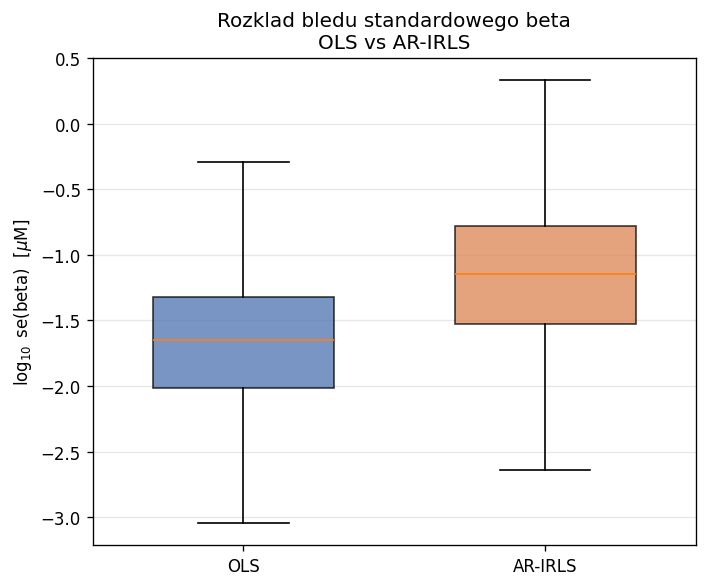

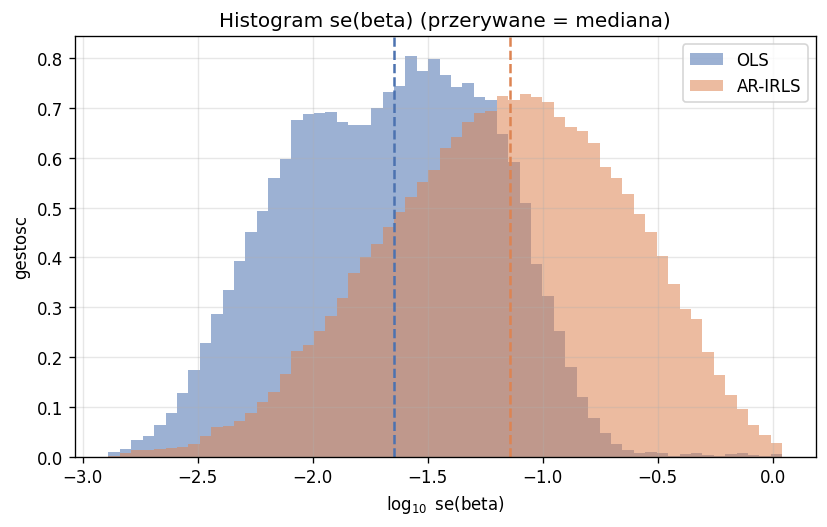

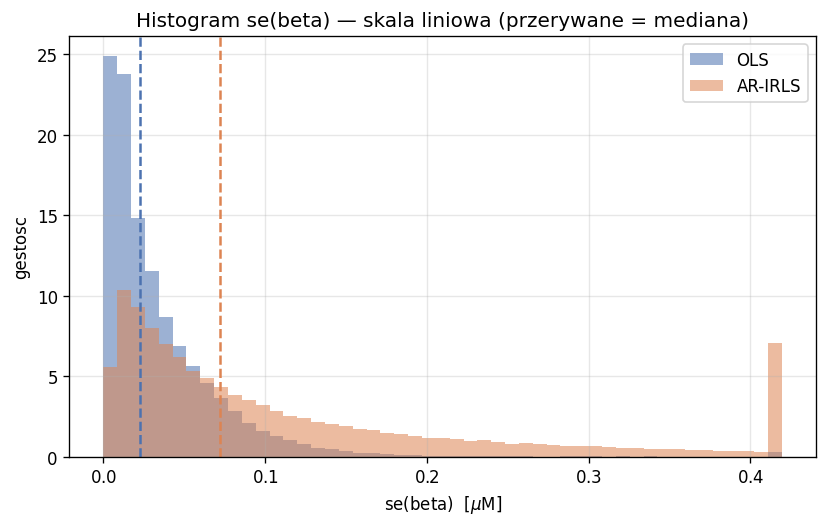

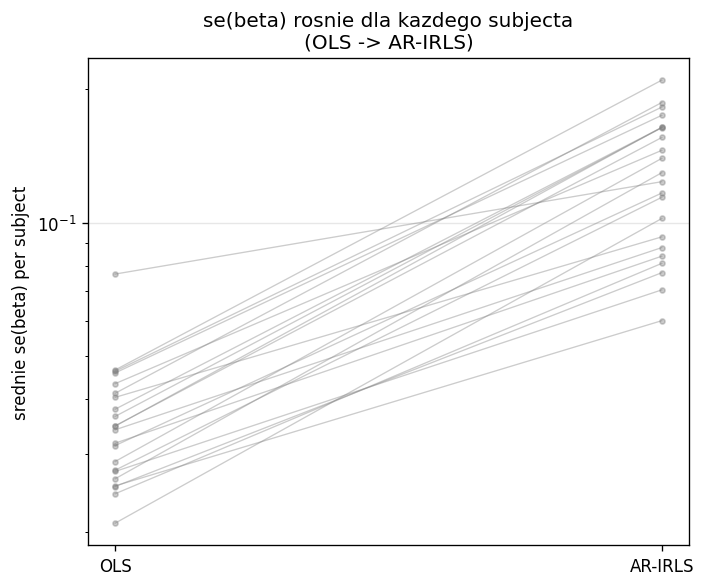

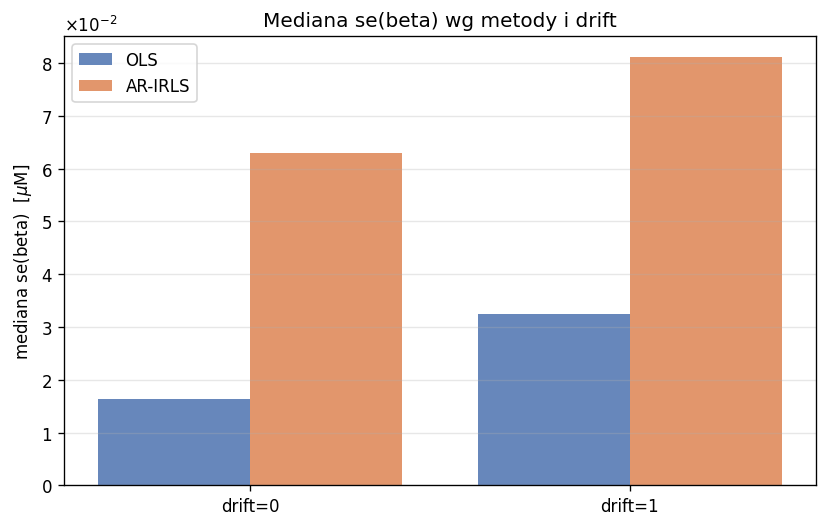

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

def sci_axis(ax, which="x"):

    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((-2, 2))        
    axis = ax.xaxis if which == "x" else ax.yaxis
    axis.set_major_formatter(fmt)
    ax.ticklabel_format(axis=which, style="sci", scilimits=(-2, 2))
BASE = Path(r"/Users/antek/Desktop/Praca Magisterska kody/LOSO Results")
BET  = BASE / "betas"
OUT  = BASE

FILES = {
    "OLS":     [BET / "OLS__Gamma_t2_s4__d0_with_se.csv",
                BET / "OLS__Gamma_t2_s4__d1_with_se.csv"],
    "AR-IRLS": [BET / "AR_IRLS__Gamma_t2_s4__d0_with_se.csv",
                BET / "AR_IRLS__Gamma_t2_s4__d1_with_se.csv"],
}
COL = {"OLS": "#4C72B0", "AR-IRLS": "#DD8452", "OLS_SS": "#55A868"}


def load_se_long(path, method):
    d = pd.read_csv(path)
    se_cols = sorted([c for c in d.columns if c.startswith("se") and c[2:].isdigit()])
    long = d.melt(
        id_vars=["subject", "label", "drift"],
        value_vars=se_cols, var_name="reg", value_name="se",
    )
    long["method"] = method
    return long

frames = []
for method, paths in FILES.items():
    for p in paths:
        if p.exists():
            frames.append(load_se_long(p, method))
        else:
            print(f"[brak pliku] {p}")
allse = pd.concat(frames, ignore_index=True)
allse = allse[np.isfinite(allse["se"])]
allse = allse[allse["se"] > 0]              

UNIT_SCALE = 1e6
UNIT_LABEL = r"$\mu$M"
allse["se"] = allse["se"] * UNIT_SCALE
allse["log10_se"] = np.log10(allse["se"])      

desc = allse.groupby("method")["se"].agg(
    n="count", mean="mean", median="median", std="std",
    q25=lambda x: x.quantile(.25), q75=lambda x: x.quantile(.75),
)

by_drift = allse.groupby(["method", "drift"])["se"].agg(
    mean="mean", median="median", std="std"
).round(4)
by_drift.to_csv(OUT / "se_by_drift.csv")

per_subj = (allse.groupby(["method", "subject"])["se"]
            .mean().reset_index())
piv = per_subj.pivot(index="subject", columns="method", values="se")
if {"OLS", "AR-IRLS"}.issubset(piv.columns):
    a, o = piv["AR-IRLS"].values, piv["OLS"].values
    ratio = np.nanmean(a / o)
    w_stat, w_p = stats.wilcoxon(a, o)
    print(f"srednia se OLS     = {np.nanmean(o):.3e}")
    print(f"srednia se AR-IRLS = {np.nanmean(a):.3e}")
    print(f"sredni stosunek AR/OLS = {ratio:.2f}x")
    print(f"Wilcoxon sparowany: stat={w_stat:.1f}, p={w_p:.2e}")
    print("=> AR-IRLS daje istotnie wieksze se(beta) niz OLS." if w_p < .05
          else "=> brak istotnej roznicy.")

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
methods = [m for m in ["OLS", "OLS_SS", "AR-IRLS"] if m in allse["method"].unique()]


fig, ax = plt.subplots(figsize=(6, 5))
data = [allse[allse["method"] == m]["log10_se"] for m in methods]
bp = ax.boxplot(data, tick_labels=methods, patch_artist=True, widths=0.6, showfliers=False)
for patch, m in zip(bp["boxes"], methods):
    patch.set_facecolor(COL[m]); patch.set_alpha(0.75)
ax.set_ylabel(rf"$\log_{{10}}$ se(beta)  [{UNIT_LABEL}]")
ax.set_title("Rozklad bledu standardowego beta\nOLS vs AR-IRLS")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout(); fig.savefig(OUT / "se_boxplot.pdf", bbox_inches="tight")

fig2, ax = plt.subplots(figsize=(7, 4.5))
lo, hi = allse["log10_se"].quantile([.001, .999])
bins = np.linspace(lo, hi, 60)
for m in methods:
    v = allse[allse["method"] == m]["log10_se"]
    ax.hist(v, bins=bins, alpha=0.55, label=m, color=COL[m], density=True)
    ax.axvline(v.median(), color=COL[m], ls="--", lw=1.5)
ax.set_xlabel(r"$\log_{10}$ se(beta)"); ax.set_ylabel("gestosc")
ax.set_title("Histogram se(beta) (przerywane = mediana)")
ax.legend(); ax.grid(alpha=0.3)
fig2.tight_layout(); fig2.savefig(OUT / "se_histogram.pdf", bbox_inches="tight")

fig2b, ax = plt.subplots(figsize=(7, 4.5))
hi = allse["se"].quantile(.97)                 
bins = np.linspace(0, hi, 50)
for m in methods:
    v = allse[allse["method"] == m]["se"]
    ax.hist(v.clip(upper=hi), bins=bins, alpha=0.55, label=m, color=COL[m], density=True)
    ax.axvline(v.median(), color=COL[m], ls="--", lw=1.5)
ax.set_xlabel(f"se(beta)  [{UNIT_LABEL}]"); ax.set_ylabel("gestosc")
ax.set_title("Histogram se(beta) — skala liniowa (przerywane = mediana)")
sci_axis(ax, "x")
ax.legend(); ax.grid(alpha=0.3)
fig2b.tight_layout(); fig2b.savefig(OUT / "se_histogram_linear.pdf", bbox_inches="tight")

if {"OLS", "AR-IRLS"}.issubset(piv.columns):
    fig3, ax = plt.subplots(figsize=(6, 5))
    for i, subj in enumerate(piv.index):
        ax.plot([0, 1], [piv.loc[subj, "OLS"], piv.loc[subj, "AR-IRLS"]],
                color="gray", alpha=0.4, lw=0.8, marker="o", ms=3)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["OLS", "AR-IRLS"])
    ax.set_ylabel("srednie se(beta) per subject")
    ax.set_yscale("log")
    ax.set_title("se(beta) rosnie dla kazdego subjecta\n(OLS -> AR-IRLS)")
    ax.grid(axis="y", alpha=0.3)
    fig3.tight_layout(); fig3.savefig(OUT / "se_per_subject.pdf", bbox_inches="tight")


fig4, ax = plt.subplots(figsize=(7, 4.5))
agg = allse.groupby(["method", "drift"])["se"].median().reset_index()
drifts = sorted(allse["drift"].unique()); w = 0.8 / len(methods)
xpos = np.arange(len(drifts))
for k, m in enumerate(methods):
    vals = [agg[(agg["method"] == m) & (agg["drift"] == d)]["se"].values for d in drifts]
    vals = [v[0] if len(v) else np.nan for v in vals]
    ax.bar(xpos + k * w, vals, w, label=m, color=COL[m], alpha=0.85)
ax.set_xticks(xpos + w * (len(methods) - 1) / 2)
ax.set_xticklabels([f"drift={d}" for d in drifts])
ax.set_ylabel(f"mediana se(beta)  [{UNIT_LABEL}]"); ax.set_title("Mediana se(beta) wg metody i drift")
sci_axis(ax, "y")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig4.tight_layout(); fig4.savefig(OUT / "se_median_by_drift.pdf", bbox_inches="tight")

desc.to_csv(OUT / "se_stats_summary.csv")

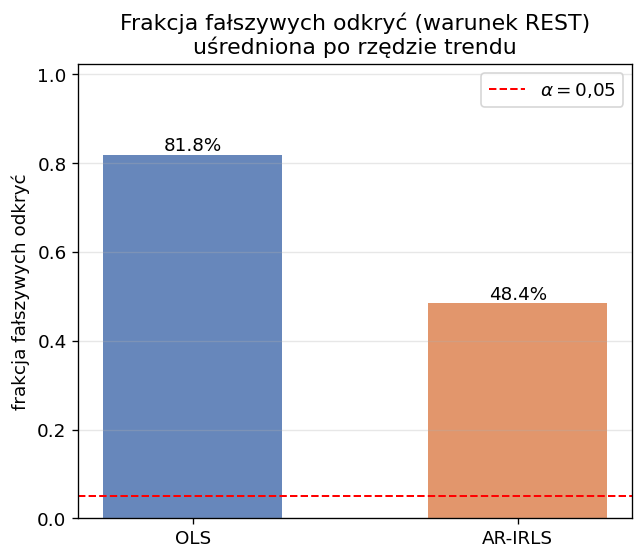

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path(r"/Users/antek/Desktop/Praca Magisterska kody/LOSO Results")
BET  = BASE / "betas"
OUT  = BASE


ALPHA_T = 1.96         
SE_CLIP = 1e-12

FILES = {
    "OLS":     [BET / "OLS__Gamma_t2_s4__d0_with_se.csv",
                BET / "OLS__Gamma_t2_s4__d1_with_se.csv"],
    "AR-IRLS": [BET / "AR_IRLS__Gamma_t2_s4__d0_with_se.csv",
                BET / "AR_IRLS__Gamma_t2_s4__d1_with_se.csv"],
}
COL = {"OLS": "#4C72B0", "AR-IRLS": "#DD8452"}


def false_discovery_fraction(path):
    d = pd.read_csv(path)
    drift = int(d["drift"].iloc[0])
    rest = d[d["label"] == "REST"]
    bcols = sorted([c for c in d.columns if c.startswith("b") and c[1:].isdigit()])
    scols = sorted([c for c in d.columns if c.startswith("se") and c[2:].isdigit()])

    B = rest[bcols].values.astype(float)
    S = rest[scols].values.astype(float)
    S = np.where(np.abs(S) < SE_CLIP, SE_CLIP, S)
    T = B / S

    mask = np.isfinite(T)
    n_total = mask.sum()
    n_fp = (np.abs(T[mask]) > ALPHA_T).sum()
    return drift, n_fp / n_total

rows = []
for method, paths in FILES.items():
    for p in paths:
        if not p.exists():
            print(f"[brak pliku] {p}"); continue
        drift, frac = false_discovery_fraction(p)
        rows.append({"method": method, "drift": drift, "false_discovery": frac})

res = pd.DataFrame(rows)


avg = res.groupby("method")["false_discovery"].mean()


plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
methods = [m for m in ["OLS", "AR-IRLS"] if m in avg.index]

fig, ax = plt.subplots(figsize=(5.5, 4.8))
bars = ax.bar(methods, [avg[m] for m in methods],
              color=[COL[m] for m in methods], alpha=0.85, width=0.55)
for b, m in zip(bars, methods):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(),
            f"{avg[m]*100:.1f}%", ha="center", va="bottom", fontsize=11)
ax.axhline(0.05, color="red", ls="--", lw=1.2,
           label=r"$\alpha=0{,}05$")
ax.set_ylabel("frakcja fałszywych odkryć")
ax.set_title("Frakcja fałszywych odkryć (warunek REST)\nuśredniona po rzędzie trendu")
ax.set_ylim(0, max(avg.max() * 1.25, 0.07))
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "false_discovery_fraction.pdf", bbox_inches="tight")

res.to_csv(OUT / "false_discovery_fraction.csv", index=False)